In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


# Notebook display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.1f}'.format)
plt.style.use('seaborn-v0_8-whitegrid')
print('Libraries loaded!!!')

Libraries loaded!!!


In [2]:
np.random.seed(42)
N = 500

# ----------- Age (35-85), slightly right skew via gamma -----------------
# NumPy's gamma has no loc; shift after sampling. Use size=N for one draw per patient.
age = np.clip(np.random.gamma(shape=6, scale=8, size=N) + 32, 35, 85).astype(int)

# -------------- Systolic BP (base normal + hypertensive outlier cluster) ------------
bp_base = np.random.normal(loc=130, scale=18, size=N)
bp_outlier = np.random.normal(loc=185, scale=8, size=30)
bp_systolic = np.clip(
    np.concatenate([bp_base[:470], bp_outlier]),
    90, 200
).astype(int)
np.random.shuffle(bp_systolic)

# --- LDL Cholesterol (roughly normal, clinically plausible) ---
cholesterol_ldl = np.clip(
    np.random.normal(loc=130, scale=35, size=N),
    60, 250
).astype(int)

# --- Blood Glucose (right-skewed — diabetic tail) ---
glucose_base     = np.random.normal(loc=95, scale=18, size=N)
glucose_diabetic = np.random.normal(loc=280, scale=60, size=60)  # 60 diabetic pts
blood_glucose = np.clip(
    np.concatenate([glucose_base[:440], glucose_diabetic]),
    70, 400
).astype(int)
np.random.shuffle(blood_glucose)


# --- Hospital Stay Days (heavily right-skewed — most short, few very long) ---
hospital_stay = np.clip(
    np.random.exponential(scale=4, size=N),
    1, 30
).astype(int)


# --- 30-Day Readmission (binary, ~22% positive rate) ---
# Correlated with longer stay + higher glucose
readmit_prob = 1 / (1 + np.exp(-(
    -2.5
    + 0.04 * hospital_stay
    + 0.008 * blood_glucose
    + 0.01 * age
)))
readmitted = (np.random.random(N) < readmit_prob).astype(int)

df = pd.DataFrame({
    'Patient_ID'           : [f'P{str(i).zfill(3)}' for i in range(1, N+1)],
    'Age'                  : age,
    'BP_Systolic'          : bp_systolic,
    'Cholesterol_LDL'      : cholesterol_ldl,
    'Blood_Glucose'        : blood_glucose,
    'Hospital_Stay_Days'   : hospital_stay,
    'Readmitted_30_Days'   : readmitted,
})


print(f"Dataset created: {df.shape[0]} patients × {df.shape[1]} columns")
print(f"Readmission rate: {df['Readmitted_30_Days'].mean():.1%}")
df.head(8)

Dataset created: 500 patients × 7 columns
Readmission rate: 34.4%


,Patient_ID,Age,BP_Systolic,Cholesterol_LDL,Blood_Glucose,Hospital_Stay_Days,Readmitted_30_Days
0,P001,85,171,150,371,1,1
1,P002,74,180,141,70,3,0
2,P003,73,116,136,77,5,0
3,P004,73,129,117,86,1,0
4,P005,85,162,141,94,4,1
5,P006,85,134,119,107,3,1
6,P007,68,136,135,70,1,1
7,P008,85,115,176,162,1,0


In [3]:
df.describe().round(1)

,Age,BP_Systolic,Cholesterol_LDL,Blood_Glucose,Hospital_Stay_Days,Readmitted_30_Days
count,500.0,500.0,500.0,500.0,500.0,500.0
mean,74.2,134.8,129.9,118.4,3.5,0.3
std,11.0,21.6,32.7,66.6,3.6,0.5
min,39.0,90.0,60.0,70.0,1.0,0.0
25%,66.0,120.0,108.0,84.0,1.0,0.0
50%,77.0,133.0,129.5,99.0,2.0,0.0
75%,85.0,146.0,152.0,113.0,4.0,1.0
max,85.0,200.0,239.0,400.0,24.0,1.0


In [ ]:

#Run those three cells in order and you're set. A couple of things worth knowing about the design of this dataset:
#The readmission column isn't purely random — it's generated using a logistic function that gives higher readmission probability to patients with longer stays, higher glucose, and older age. That's intentional: when we get to correlation in Topic 8, you'll actually be able to detect those relationships in the data, just like a real ML pipeline would.
#The glucose and blood pressure columns have deliberate outlier clusters baked in — 60 "diabetic" patients with very high glucose, and 30 "hypertensive" patients with very high BP. These will become very visible when we plot histograms and boxplots in Topics 6 and 7, and they'll give us real, meaningful outliers to reason about rather than contrived ones.

![Central tendency](../img/central_tendency.png)

In [4]:
from scipy import stats

col = 'Blood_Glucose'

# --------------------- Compute the three measures -------------
mean_val = df[col].mean()
median_val = df[col].median()
mode_val = df[col].mode()[0] # .mode() returns a Series; [0] = most frequent


print(f"Blood Glucose — Central Tendency")
print(f"{'─'*38}")
print(f"  Mean   (x̄) : {mean_val:.1f} mg/dL")
print(f"  Median (M)  : {median_val:.1f} mg/dL")
print(f"  Mode        : {mode_val:.1f} mg/dL")
print(f"{'─'*38}")
print(f"  Mean − Median gap: {mean_val - median_val:.1f} mg/dL")
print(f"  ↑ Positive gap signals RIGHT SKEW (outliers pulling mean up)")

Blood Glucose — Central Tendency
──────────────────────────────────────
  Mean   (x̄) : 118.4 mg/dL
  Median (M)  : 99.0 mg/dL
  Mode        : 70.0 mg/dL
──────────────────────────────────────
  Mean − Median gap: 19.4 mg/dL
  ↑ Positive gap signals RIGHT SKEW (outliers pulling mean up)


In [17]:
# Compare with Cholesterol LDL — more symmetrically distributed
col2 = 'Cholesterol_LDL'

mean2   = df[col2].mean()
median2 = df[col2].median()
mode2   = df[col2].mode()[0]

print(f"Cholesterol LDL — Central Tendency")
print(f"{'─'*38}")
print(f"  Mean   (x̄) : {mean2:.1f} mg/dL")
print(f"  Median (M)  : {median2:.1f} mg/dL")
print(f"  Mode        : {mode2:.1f} mg/dL")
print(f"{'─'*38}")
print(f"  Mean − Median gap: {mean2 - median2:.1f} mg/dL")
print(f"  ↑ Near-zero gap signals SYMMETRY (mean ≈ median ≈ mode)")

Cholesterol LDL — Central Tendency
──────────────────────────────────────
  Mean   (x̄) : 129.9 mg/dL
  Median (M)  : 129.5 mg/dL
  Mode        : 60.0 mg/dL
──────────────────────────────────────
  Mean − Median gap: 0.4 mg/dL
  ↑ Near-zero gap signals SYMMETRY (mean ≈ median ≈ mode)


⚠️ Common Pitfall: Many beginners default to the mean for everything. But when your data has outliers or is skewed (like hospital stay days, income, or our glucose column), the mean can be deeply misleading. Always compute both mean and median first — a large gap between them is your warning signal to investigate further.

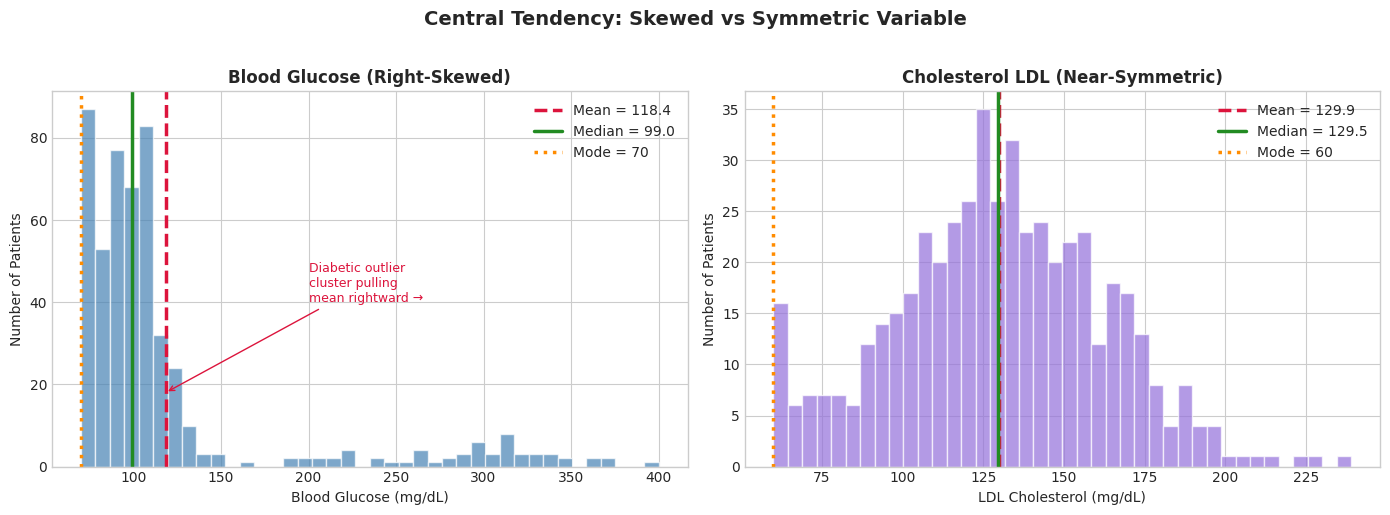

Chart saved as central_tendency.png


In [18]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Central Tendency: Skewed vs Symmetric Variable', 
             fontsize=14, fontweight='bold', y=1.02)

# ── Left plot: Blood Glucose (skewed) ──────────────────────────────
ax1 = axes[0]
ax1.hist(df['Blood_Glucose'], bins=40, color='steelblue', 
         alpha=0.7, edgecolor='white')

mean_g   = df['Blood_Glucose'].mean()
median_g = df['Blood_Glucose'].median()
mode_g   = df['Blood_Glucose'].mode()[0]

ax1.axvline(mean_g,   color='crimson',     linewidth=2.5, 
            linestyle='--', label=f'Mean = {mean_g:.1f}')
ax1.axvline(median_g, color='forestgreen', linewidth=2.5, 
            linestyle='-',  label=f'Median = {median_g:.1f}')
ax1.axvline(mode_g,   color='darkorange',  linewidth=2.5, 
            linestyle=':',  label=f'Mode = {mode_g:.0f}')

ax1.set_title('Blood Glucose (Right-Skewed)', fontweight='bold')
ax1.set_xlabel('Blood Glucose (mg/dL)')
ax1.set_ylabel('Number of Patients')
ax1.legend(fontsize=10)
ax1.annotate('Diabetic outlier\ncluster pulling\nmean rightward →',
             xy=(mean_g, 18), xytext=(200, 40),
             arrowprops=dict(arrowstyle='->', color='crimson'),
             fontsize=9, color='crimson')

# ── Right plot: Cholesterol LDL (symmetric) ────────────────────────
ax2 = axes[1]
ax2.hist(df['Cholesterol_LDL'], bins=40, color='mediumpurple', 
         alpha=0.7, edgecolor='white')

mean_c   = df['Cholesterol_LDL'].mean()
median_c = df['Cholesterol_LDL'].median()
mode_c   = df['Cholesterol_LDL'].mode()[0]

ax2.axvline(mean_c,   color='crimson',     linewidth=2.5, 
            linestyle='--', label=f'Mean = {mean_c:.1f}')
ax2.axvline(median_c, color='forestgreen', linewidth=2.5, 
            linestyle='-',  label=f'Median = {median_c:.1f}')
ax2.axvline(mode_c,   color='darkorange',  linewidth=2.5, 
            linestyle=':',  label=f'Mode = {mode_c:.0f}')

ax2.set_title('Cholesterol LDL (Near-Symmetric)', fontweight='bold')
ax2.set_xlabel('LDL Cholesterol (mg/dL)')
ax2.set_ylabel('Number of Patients')
ax2.legend(fontsize=10)

plt.tight_layout()
plt.savefig('central_tendency.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved as central_tendency.png")

# 2. The Medical Analogy — Before Any Math
Imagine two hospital wards, both with a mean systolic BP of 130 mmHg:
`Ward A` — every patient has BP between 125 and 135 mmHg. Tight, stable, predictable. Your nursing team can write one protocol and it covers everyone.
`Ward B` — patients range from 90 to 190 mmHg. Same average, completely different reality. Some patients are in hypotensive shock, others are hypertensive crisis. One protocol covers nobody well.
That spread is what dispersion measures. Now let's meet the three tools that quantify it:

`Range` is the security guard who only checks the front and back of the queue — it only sees the two most extreme patients and ignores everyone in between.
`Variance` is the meticulous registrar who measures every patient's distance from the mean, squares it to avoid negatives cancelling out, and averages those squared distances.
`Standard Deviation` is the *variance* brought back to the original unit — mg/dL, mmHg, days — so it's clinically interpretable again. It's the one you'll use most.

![Measures of Dispersion](../img/dispersion.png)

In [19]:
col = 'BP_Systolic'

# --- Range ---
bp_range = df[col].max() - df[col].min()

# --- Variance (sample) — ddof=1 means divide by n-1 ---
bp_variance = df[col].var(ddof=1)

# --- Standard Deviation (sample) ---
bp_std = df[col].std(ddof=1)

# --- Mean for reference ---
bp_mean = df[col].mean()

print(f"BP Systolic — Measures of Dispersion")
print(f"{'─'*42}")
print(f"  Min              : {df[col].min()} mmHg")
print(f"  Max              : {df[col].max()} mmHg")
print(f"  Range            : {bp_range} mmHg")
print(f"{'─'*42}")
print(f"  Mean (x̄)         : {bp_mean:.1f} mmHg")
print(f"  Variance (s²)    : {bp_variance:.1f} mmHg²")
print(f"  Std Dev (s)      : {bp_std:.1f} mmHg")
print(f"{'─'*42}")
print(f"  Interpretation:")
print(f"  A 'typical' patient is {bp_mean:.1f} ± {bp_std:.1f} mmHg")
print(f"  i.e., roughly {bp_mean-bp_std:.1f} – {bp_mean+bp_std:.1f} mmHg")

BP Systolic — Measures of Dispersion
──────────────────────────────────────────
  Min              : 90 mmHg
  Max              : 200 mmHg
  Range            : 110 mmHg
──────────────────────────────────────────
  Mean (x̄)         : 134.8 mmHg
  Variance (s²)    : 464.6 mmHg²
  Std Dev (s)      : 21.6 mmHg
──────────────────────────────────────────
  Interpretation:
  A 'typical' patient is 134.8 ± 21.6 mmHg
  i.e., roughly 113.2 – 156.3 mmHg


In [20]:
# Walk through variance step-by-step on first 6 patients
# so the formula stops feeling abstract

sample = df['BP_Systolic'].head(6).values
mean_s = sample.mean()

print(f"6-patient sample BPs: {sample}")
print(f"Sample mean: {mean_s:.1f} mmHg\n")
print(f"{'Patient':<10} {'BP':>6} {'Deviation (x-x̄)':>18} {'Deviation²':>12}")
print("─" * 50)

deviations_sq = []
for i, bp in enumerate(sample):
    dev = bp - mean_s
    dev_sq = dev ** 2
    deviations_sq.append(dev_sq)
    print(f"P{i+1:<9} {bp:>6} {dev:>+18.1f} {dev_sq:>12.1f}")

print("─" * 50)
print(f"{'Sum of squared devs:':>36} {sum(deviations_sq):>9.1f}")
print(f"{'Variance (÷ n-1=5):':>36} {sum(deviations_sq)/5:>9.1f}")
print(f"{'Std Dev (√variance):':>36} {(sum(deviations_sq)/5)**0.5:>9.1f}")

6-patient sample BPs: [171 180 116 129 162 134]
Sample mean: 148.7 mmHg

Patient        BP   Deviation (x-x̄)   Deviation²
──────────────────────────────────────────────────
P1            171              +22.3        498.8
P2            180              +31.3        981.8
P3            116              -32.7       1067.1
P4            129              -19.7        386.8
P5            162              +13.3        177.8
P6            134              -14.7        215.1
──────────────────────────────────────────────────
                Sum of squared devs:    3327.3
                 Variance (÷ n-1=5):     665.5
                Std Dev (√variance):      25.8


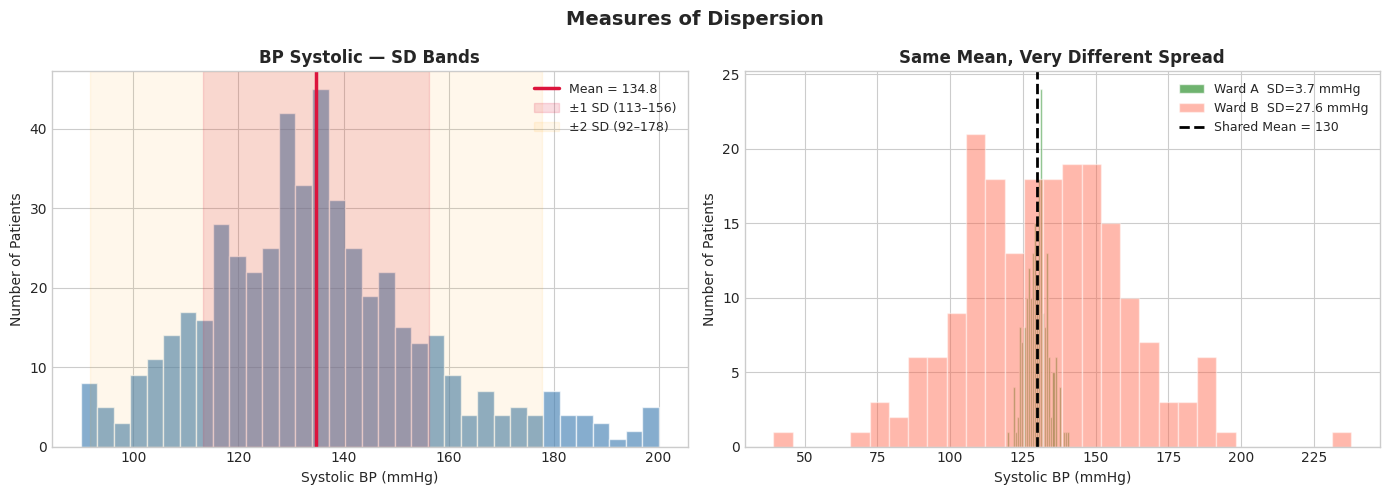

Chart saved as dispersion.png


In [22]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Measures of Dispersion', fontsize=14, fontweight='bold')

# ── Left: BP Systolic with SD bands ───────────────────────────────
ax1 = axes[0]
bp_mean = df['BP_Systolic'].mean()
bp_std  = df['BP_Systolic'].std(ddof=1)

ax1.hist(df['BP_Systolic'], bins=35, color='steelblue',
         alpha=0.65, edgecolor='white')
ax1.axvline(bp_mean, color='crimson', linewidth=2.5,
            label=f'Mean = {bp_mean:.1f}')

# Shade ±1 SD band
ax1.axvspan(bp_mean - bp_std, bp_mean + bp_std,
            alpha=0.15, color='crimson',
            label=f'±1 SD ({bp_mean-bp_std:.0f}–{bp_mean+bp_std:.0f})')

# Shade ±2 SD band
ax1.axvspan(bp_mean - 2*bp_std, bp_mean + 2*bp_std,
            alpha=0.08, color='orange',
            label=f'±2 SD ({bp_mean-2*bp_std:.0f}–{bp_mean+2*bp_std:.0f})')

ax1.set_title('BP Systolic — SD Bands', fontweight='bold')
ax1.set_xlabel('Systolic BP (mmHg)')
ax1.set_ylabel('Number of Patients')
ax1.legend(fontsize=9)

# ── Right: Ward A vs Ward B analogy ───────────────────────────────
ax2 = axes[1]
np.random.seed(42)
ward_a = np.random.normal(loc=130, scale=4,  size=200)  # tight spread
ward_b = np.random.normal(loc=130, scale=28, size=200)  # wide spread

ax2.hist(ward_a, bins=30, alpha=0.65, color='forestgreen',
         label=f'Ward A  SD={ward_a.std():.1f} mmHg', edgecolor='white')
ax2.hist(ward_b, bins=30, alpha=0.45, color='tomato',
         label=f'Ward B  SD={ward_b.std():.1f} mmHg', edgecolor='white')
ax2.axvline(130, color='black', linewidth=2,
            linestyle='--', label='Shared Mean = 130')

ax2.set_title('Same Mean, Very Different Spread', fontweight='bold')
ax2.set_xlabel('Systolic BP (mmHg)')
ax2.set_ylabel('Number of Patients')
ax2.legend(fontsize=9)

plt.tight_layout()
plt.savefig('dispersion.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved as dispersion.png")

`What to look for when your chart renders:`

`Left panel`: The dark red band (±1 SD) captures the bulk of your patients — roughly 68% in a normal distribution. The orange band (±2 SD) sweeps out to cover ~95%. Patients sitting outside the orange band are your statistical outliers — and you can literally see the hypertensive cluster sitting beyond the right edge.

`Right panel`: This is your Ward A vs Ward B analogy made visual. Both histograms are centred on 130 mmHg, but Ward B (red) is so spread out it's nearly flat — patients are distributed from hypotensive to hypertensive crisis. Same mean, completely different clinical reality. If you only reported the mean, you'd miss this entirely.

### Topic 3: Bessel's Correction — Why Sample Variance Uses n−1

- 1. Plain-Language Definition: When you calculate variance from a **sample** (a subset of patients) rather than the entire population, dividing by `n` consistently *underestimates* the true population variance. Bessel's correction is the fix — dividing by `n−1` instead of `n` to compensate for that systematic underestimation.
It's not a rounding trick. It's not a convention. It has a precise mathematical reason — and by the end of this section you'll understand it intuitively, not just mechanically

- 2. The Medical Analogy — Before Any Math

Imagine you want to know the `true variability` in fasting blood glucose across all diabetic patients in Ghana — that's your population. Obviously you can't measure all of them, so you recruit a sample of `10 patients` from one clinic.
Here's the subtle problem: your sample, almost by definition, is less extreme than the full population.
Think about it. The most severe diabetic cases — glucose readings of `380, 390, 400` — are rare. They're unlikely to all land in your 10-patient sample. Your sample will naturally cluster a little closer to the `centre` than the true population does. So if you calculate variance using those 10 patients and divide by `n=10`, you get a number that is *systematically too small* — it underestimates how variable the full population truly is.
Dividing by `n−1=9` instead inflates the variance slightly to compensate for the extremes your sample probably missed. That correction is `Bessel's correction`.
The −1 is essentially the mathematical price you pay for *not knowing the true population mean* and having to estimate it from the same sample.

- 3. The Intuition — Degrees of Freedom
This is the concept that unlocks everything:
When you calculate sample variance, you first compute the sample mean xˉ\bar{x}
xˉ from your data. The moment you do that, you've used up **one piece of information**. Your ndata points now only have **n−1 independent pieces of information left** to estimate spread — because once you know n−1 of the deviations from the mean, the last one is *completely determined* (they must all sum to zero).

`Clinical parallel: Imagine 5 patients whose average BP is exactly 130 mmHg. Once you know 4 of their individual BPs, the 5th is no longer free — it's forced by the constraint that the mean must be 130. That 5th value has lost its "freedom." You only had 4 degrees of freedom, not 5.`

So dividing by n−1 rather than n is dividing by the true number of *free* pieces of information in your sample. That's why it's called **degrees of freedom**.

- 4. The Math — Why n−1?
![Bessel's Correction](../img/bessel.png)

In [6]:
col = 'Blood_Glucose'

# Treat our full 500-patient dataset as the "population"
population_mean     = df[col].mean()
population_variance = df[col].var(ddof=0)   # divide by N — true population

print(f"POPULATION (all 500 patients)")
print(f"{'─'*42}")
print(f"  Mean              : {population_mean:.2f} mg/dL")
print(f"  Variance (÷ N)    : {population_variance:.2f} mg/dL²")
print(f"  Std Dev  (÷ N)    : {population_variance**0.5:.2f} mg/dL\n")

# Now draw a small sample of 15 patients — like a pilot study
np.random.seed(7)
sample_15 = df[col].sample(n=15)

var_biased   = sample_15.var(ddof=0)   # divide by n   → biased
var_unbiased = sample_15.var(ddof=1)   # divide by n-1 → Bessel's correction

print(f"SAMPLE (15 patients — like a small clinic study)")
print(f"{'─'*42}")
print(f"  Sample mean             : {sample_15.mean():.2f} mg/dL")
print(f"  Variance (÷ n,   ddof=0): {var_biased:.2f}  ← underestimates population")
print(f"  Variance (÷ n-1, ddof=1): {var_unbiased:.2f}  ← Bessel corrected")
print(f"  True population variance: {population_variance:.2f}")
print(f"{'─'*42}")
print(f"  Biased error   : {var_biased - population_variance:+.2f} mg/dL²")
print(f"  Corrected error: {var_unbiased - population_variance:+.2f} mg/dL²")

POPULATION (all 500 patients)
──────────────────────────────────────────
  Mean              : 118.35 mg/dL
  Variance (÷ N)    : 4428.52 mg/dL²
  Std Dev  (÷ N)    : 66.55 mg/dL

SAMPLE (15 patients — like a small clinic study)
──────────────────────────────────────────
  Sample mean             : 119.47 mg/dL
  Variance (÷ n,   ddof=0): 4054.38  ← underestimates population
  Variance (÷ n-1, ddof=1): 4343.98  ← Bessel corrected
  True population variance: 4428.52
──────────────────────────────────────────
  Biased error   : -374.14 mg/dL²
  Corrected error: -84.54 mg/dL²


In [7]:
# Draw 1,000 random samples of size 15 from our dataset
# Compute both variance estimates each time
# If Bessel is right, the average of ddof=1 estimates should
# converge to the true population variance

n_simulations = 1000
sample_size   = 15
true_var      = df['Blood_Glucose'].var(ddof=0)

biased_vars   = []
corrected_vars = []

np.random.seed(42)
for _ in range(n_simulations):
    s = df['Blood_Glucose'].sample(n=sample_size)
    biased_vars.append(s.var(ddof=0))
    corrected_vars.append(s.var(ddof=1))

print(f"Results over {n_simulations} simulated studies (n=15 each)")
print(f"{'─'*50}")
print(f"  True population variance      : {true_var:.2f}")
print(f"{'─'*50}")
print(f"  Avg biased variance   (ddof=0): {np.mean(biased_vars):.2f}  ← consistently LOW")
print(f"  Avg corrected variance(ddof=1): {np.mean(corrected_vars):.2f}  ← converges to truth")
print(f"{'─'*50}")
print(f"  Biased undershoot    : {np.mean(biased_vars) - true_var:+.2f} mg/dL²")
print(f"  Corrected error      : {np.mean(corrected_vars) - true_var:+.2f} mg/dL²")
print(f"\n  Ratio check: n/(n-1) = {sample_size}/{sample_size-1} = {sample_size/(sample_size-1):.4f}")
print(f"  Corrected / Biased avg        = {np.mean(corrected_vars)/np.mean(biased_vars):.4f}")
print(f"  ↑ These should match — proving Bessel's correction is exactly n/(n-1)")

Results over 1000 simulated studies (n=15 each)
──────────────────────────────────────────────────
  True population variance      : 4428.52
──────────────────────────────────────────────────
  Avg biased variance   (ddof=0): 4179.18  ← consistently LOW
  Avg corrected variance(ddof=1): 4477.69  ← converges to truth
──────────────────────────────────────────────────
  Biased undershoot    : -249.34 mg/dL²
  Corrected error      : +49.17 mg/dL²

  Ratio check: n/(n-1) = 15/14 = 1.0714
  Corrected / Biased avg        = 1.0714
  ↑ These should match — proving Bessel's correction is exactly n/(n-1)


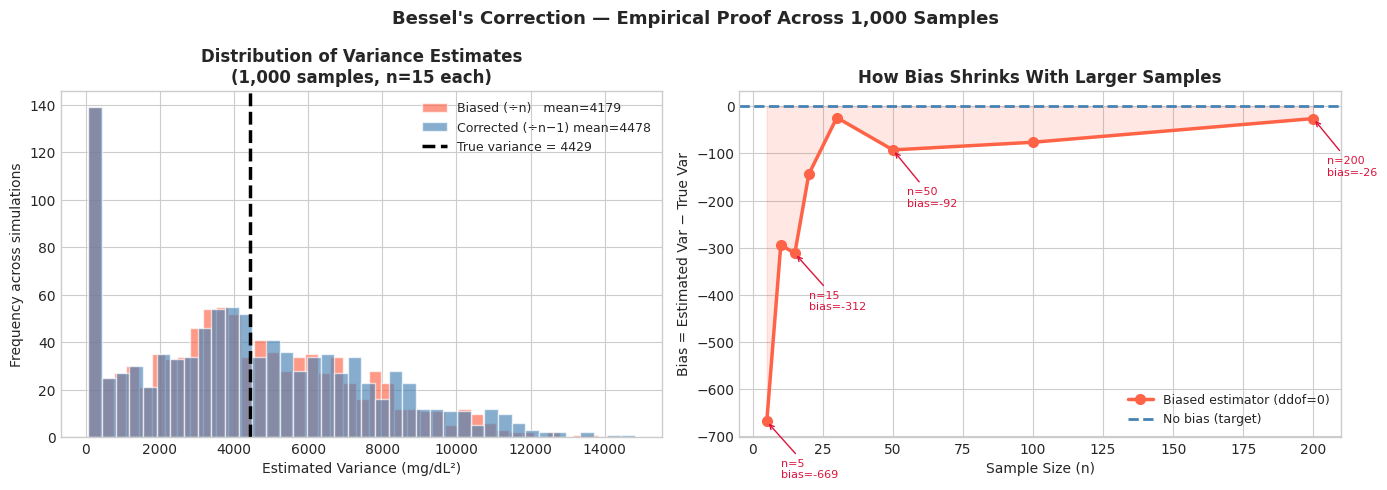

Chart saved as bessels_correction.png


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Bessel's Correction — Empirical Proof Across 1,000 Samples",
             fontsize=13, fontweight='bold')

true_var = df['Blood_Glucose'].var(ddof=0)

# ── Left: Distribution of both variance estimators ────────────────
ax1 = axes[0]
ax1.hist(biased_vars,    bins=40, alpha=0.65, color='tomato',
         label=f'Biased (÷n)   mean={np.mean(biased_vars):.0f}',
         edgecolor='white')
ax1.hist(corrected_vars, bins=40, alpha=0.65, color='steelblue',
         label=f'Corrected (÷n−1) mean={np.mean(corrected_vars):.0f}',
         edgecolor='white')
ax1.axvline(true_var, color='black', linewidth=2.5,
            linestyle='--', label=f'True variance = {true_var:.0f}')

ax1.set_title('Distribution of Variance Estimates\n(1,000 samples, n=15 each)',
              fontweight='bold')
ax1.set_xlabel('Estimated Variance (mg/dL²)')
ax1.set_ylabel('Frequency across simulations')
ax1.legend(fontsize=9)

# ── Right: Bias shrinks as sample size grows ──────────────────────
ax2 = axes[1]
sample_sizes = [5, 10, 15, 20, 30, 50, 100, 200]
biases = []

for n in sample_sizes:
    sims = [df['Blood_Glucose'].sample(n=n).var(ddof=0)
            for _ in range(500)]
    biases.append(np.mean(sims) - true_var)

ax2.plot(sample_sizes, biases, 'o-', color='tomato',
         linewidth=2.5, markersize=7, label='Biased estimator (ddof=0)')
ax2.axhline(0, color='steelblue', linewidth=2,
            linestyle='--', label='No bias (target)')
ax2.fill_between(sample_sizes, biases, 0,
                 alpha=0.15, color='tomato')

ax2.set_title('How Bias Shrinks With Larger Samples',
              fontweight='bold')
ax2.set_xlabel('Sample Size (n)')
ax2.set_ylabel('Bias = Estimated Var − True Var')
ax2.legend(fontsize=9)

# Annotate key clinical sample sizes
for n, b in zip(sample_sizes, biases):
    if n in [5, 15, 50, 200]:
        ax2.annotate(f'n={n}\nbias={b:.0f}',
                     xy=(n, b), xytext=(n+5, b-120),
                     fontsize=8, color='crimson',
                     arrowprops=dict(arrowstyle='->', color='crimson', lw=1))

plt.tight_layout()
plt.savefig('bessels_correction.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved as bessels_correction.png")

#### The Three-Line Summary to Carry Forward


1. Samples naturally miss the most extreme values in a population — so raw sample variance underestimates truth.
2. Dividing by n−1 instead of n corrects this — giving you an *unbiased* estimator.
3. The correction matters most when `n` is small (pilot studies, rare disease trials) and becomes negligible as n grows large.

## Topic 4: Random Variables — Discrete vs. Continuous
1. **Plain English Definition**: A random variable is simply a variable whose value is determined by the outcome of a random process — something you measure or observe from the world, where you can't predict the exact value in advance, but you can describe the pattern of possible values.
In healthcare, almost everything you measure is a random variable: a patient's blood pressure, whether they get readmitted, how many days they stay. The critical skill is knowing what type of random variable you're dealing with — because that determines every analytical decision that follows: which statistics to use, which plots to draw, which ML model to reach for.

2. **The Medical Analogy — Before Any Math**
Picture yourself doing ward rounds and recording two things for each patient:
First, you ask: "How many times has this patient been admitted this year?"
The answer has to be a whole number — 0, 1, 2, 3. A patient cannot be admitted 2.7 times. There are distinct, countable, separated steps between possible answers. That is a discrete random variable.
Second, you measure their systolic blood pressure.
The reading could be 128, or 128.3, or 128.347, or 128.3471... In theory, between any two BP readings there are infinitely many possible values. The measurement is only limited by the precision of your equipment. That is a continuous random variable.
The simplest test: "Can this variable take fractional values that make clinical sense?"

Days in hospital: fractions don't make sense → `discrete`
Blood glucose in mg/dL: 94.7 is perfectly meaningful → `continuous`

![Random Variables](../img/random.png)

In [5]:
# Step 1: Classify every column in our dataset
variable_types = {
    'Patient_ID'         : ('Neither',    'Identifier — not a random variable'),
    'Age'                : ('Continuous', 'Any value 35–85; fractions meaningful'),
    'BP_Systolic'        : ('Continuous', 'Pressure can take any real value'),
    'Cholesterol_LDL'    : ('Continuous', 'Lab value — fractional readings valid'),
    'Blood_Glucose'      : ('Continuous', 'mg/dL — fractional readings valid'),
    'Hospital_Stay_Days' : ('Discrete',   'Whole days only — cannot stay 3.7 days'),
    'Readmitted_30_Days' : ('Discrete',   'Binary: 0 or 1 — special case of discrete'),
}

print(f"{'Column':<22} {'Type':<12} {'Reasoning'}")
print("─" * 72)
for col, (vtype, reason) in variable_types.items():
    print(f"  {col:<20} {vtype:<12} {reason}")

Column                 Type         Reasoning
────────────────────────────────────────────────────────────────────────
  Patient_ID           Neither      Identifier — not a random variable
  Age                  Continuous   Any value 35–85; fractions meaningful
  BP_Systolic          Continuous   Pressure can take any real value
  Cholesterol_LDL      Continuous   Lab value — fractional readings valid
  Blood_Glucose        Continuous   mg/dL — fractional readings valid
  Hospital_Stay_Days   Discrete     Whole days only — cannot stay 3.7 days
  Readmitted_30_Days   Discrete     Binary: 0 or 1 — special case of discrete


In [6]:
# For a DISCRETE variable, we can state the probability of EXACT values
# P(X = x) is meaningful

col = 'Hospital_Stay_Days'
value_counts = df[col].value_counts().sort_index()
pmf = value_counts / len(df)     # convert counts to probabilities

print(f"PMF — Hospital Stay Days")
print(f"{'─'*40}")
print(f"  {'Stay (days)':<14} {'Count':>7} {'P(X = x)':>10}")
print(f"  {'─'*34}")
for days, prob in pmf.head(10).items():
    bar = '█' * int(prob * 200)
    print(f"  {days:<14} {value_counts[days]:>7} {prob:>10.4f}  {bar}")

print(f"\n  [showing top 10 of {pmf.shape[0]} unique values]")
print(f"\n  Verification — probabilities sum to: {pmf.sum():.4f}")
print(f"\n  Answerable questions for discrete X:")
print(f"  P(stay = 1 day)        = {pmf.get(1, 0):.4f}")
print(f"  P(stay = 3 days)       = {pmf.get(3, 0):.4f}")
print(f"  P(stay ≤ 3 days)       = {pmf[pmf.index <= 3].sum():.4f}")
print(f"  P(stay > 7 days)       = {pmf[pmf.index > 7].sum():.4f}")

PMF — Hospital Stay Days
────────────────────────────────────────
  Stay (days)      Count   P(X = x)
  ──────────────────────────────────
  1                  200     0.4000  ████████████████████████████████████████████████████████████████████████████████
  2                   62     0.1240  ████████████████████████
  3                   65     0.1300  ██████████████████████████
  4                   50     0.1000  ████████████████████
  5                   23     0.0460  █████████
  6                   27     0.0540  ██████████
  7                   14     0.0280  █████
  8                   13     0.0260  █████
  9                    9     0.0180  ███
  10                   9     0.0180  ███

  [showing top 10 of 21 unique values]

  Verification — probabilities sum to: 1.0000

  Answerable questions for discrete X:
  P(stay = 1 day)        = 0.4000
  P(stay = 3 days)       = 0.1300
  P(stay ≤ 3 days)       = 0.6540
  P(stay > 7 days)       = 0.1180


In [7]:
from scipy import stats as scipy_stats

col = 'Blood_Glucose'

print(f"PDF — Blood Glucose (Continuous)")
print(f"{'─'*46}")
print(f"  P(glucose = exactly 94)     = 0.0000  ← always zero for continuous")
print(f"  (You cannot assign probability to a single point on a continuous scale)\n")

# For continuous — probability only makes sense over RANGES (integrate the PDF)
# We approximate using the empirical CDF
glucose = df[col].sort_values().values
n = len(glucose)

# P(70 ≤ glucose ≤ 100) — normal fasting range
p_normal  = ((glucose >= 70)  & (glucose <= 100)).sum() / n
# P(100 < glucose ≤ 125) — prediabetic range
p_pre     = ((glucose > 100)  & (glucose <= 125)).sum() / n
# P(glucose > 125) — diabetic range
p_diabetic = (glucose > 125).sum() / n

print(f"  Clinically meaningful RANGE probabilities:")
print(f"  P(70  ≤ glucose ≤ 100)  Normal fasting  = {p_normal:.4f}  ({p_normal*100:.1f}% of patients)")
print(f"  P(100 < glucose ≤ 125)  Pre-diabetic    = {p_pre:.4f}  ({p_pre*100:.1f}% of patients)")
print(f"  P(glucose > 125)        Diabetic range  = {p_diabetic:.4f}  ({p_diabetic*100:.1f}% of patients)")
print(f"  {'─'*44}")
print(f"  Sum (should = 1.0)                      = {p_normal+p_pre+p_diabetic:.4f}")

PDF — Blood Glucose (Continuous)
──────────────────────────────────────────────
  P(glucose = exactly 94)     = 0.0000  ← always zero for continuous
  (You cannot assign probability to a single point on a continuous scale)

  Clinically meaningful RANGE probabilities:
  P(70  ≤ glucose ≤ 100)  Normal fasting  = 0.5280  (52.8% of patients)
  P(100 < glucose ≤ 125)  Pre-diabetic    = 0.3100  (31.0% of patients)
  P(glucose > 125)        Diabetic range  = 0.1620  (16.2% of patients)
  ────────────────────────────────────────────
  Sum (should = 1.0)                      = 1.0000


## Topic 5: Percentiles and Quartiles
A percentile tells you the value below which a given percentage of observations fall. It answers a fundamentally different question from the mean or median — instead of "what is typical?" it asks: "where does this specific value sit relative to everyone else?"

A quartile is simply a special case of percentile — the three values that cut your dataset into four equal quarters.


2. The Medical Analogy — Before Any Math
You already use percentiles every single day in clinical practice — you just may not have called them that.

Growth charts. When a paediatrician says `"this child is in the 85th percentile for weight" — they mean exactly what the definition says: 85% of children the same age weigh less than this child, and 15% weigh more. The percentile isn't judging the child's weight as good or bad in isolation — it's locating that child within the distribution of all children.`
Lab reference ranges. When a laboratory reports that normal `fasting glucose is 70–99 mg/dL, those boundaries are derived from the 2.5th and 97.5th percentiles of a healthy reference population.` A result outside that range doesn't mean the patient is definitely sick — it means they sit in the outer 5% of the distribution, which warrants clinical attention.

***Quartiles*** are the same idea, but fixed at three specific cut points:

Q1 (25th percentile): 25% of patients fall below this value
Q2 (50th percentile): the median — 50% fall below
Q3 (75th percentile): 75% of patients fall below this value

Think of quartiles as dividing your patient queue into four equal groups of 125 patients each, then recording the BP reading at each dividing line.

![Percentiles](../img/percentiles.png)





In [11]:
col = 'Blood_Glucose'

# --- Quartiles ---
Q1  = df[col].quantile(0.25)
Q2  = df[col].quantile(0.50)   # same as median
Q3  = df[col].quantile(0.75)
IQR = Q3 - Q1

# --- Clinical reference percentiles ---
p5  = df[col].quantile(0.05)
p95 = df[col].quantile(0.95)
p2_5 = df[col].quantile(0.025)
p97_5 = df[col].quantile(0.975)

print(f"Blood Glucose — Percentiles & Quartiles")
print(f"{'─'*46}")
print(f"  2.5th  percentile : {p2_5:.1f} mg/dL  ← lower ref range boundary")
print(f"  5th    percentile : {p5:.1f} mg/dL")
print(f"  Q1  (25th)        : {Q1:.1f} mg/dL  ← 25% of patients below this")
print(f"  Q2  (50th/Median) : {Q2:.1f} mg/dL  ← middle patient")
print(f"  Q3  (75th)        : {Q3:.1f} mg/dL  ← 75% of patients below this")
print(f"  95th percentile   : {p95:.1f} mg/dL")
print(f"  97.5th percentile : {p97_5:.1f} mg/dL  ← upper ref range boundary")
print(f"{'─'*46}")
print(f"  IQR (Q3 - Q1)     : {IQR:.1f} mg/dL  ← spread of middle 50%")
print(f"{'─'*46}")
print(f"\n  Clinical interpretation:")
print(f"  The middle 50% of patients have glucose between")
print(f"  {Q1:.0f} and {Q3:.0f} mg/dL — entirely within normal fasting range.")
print(f"  But the 95th percentile is {p95:.0f} mg/dL, confirming a")
print(f"  meaningful diabetic tail in the upper 5% of patients.")

Blood Glucose — Percentiles & Quartiles
──────────────────────────────────────────────
  2.5th  percentile : 70.0 mg/dL  ← lower ref range boundary
  5th    percentile : 70.0 mg/dL
  Q1  (25th)        : 84.0 mg/dL  ← 25% of patients below this
  Q2  (50th/Median) : 99.0 mg/dL  ← middle patient
  Q3  (75th)        : 113.0 mg/dL  ← 75% of patients below this
  95th percentile   : 307.0 mg/dL
  97.5th percentile : 327.6 mg/dL  ← upper ref range boundary
──────────────────────────────────────────────
  IQR (Q3 - Q1)     : 29.0 mg/dL  ← spread of middle 50%
──────────────────────────────────────────────

  Clinical interpretation:
  The middle 50% of patients have glucose between
  84 and 113 mg/dL — entirely within normal fasting range.
  But the 95th percentile is 307 mg/dL, confirming a
  meaningful diabetic tail in the upper 5% of patients.


In [12]:
# Real clinical scenario: Where does a patient with glucose = 285 mg/dL sit?
# And one with glucose = 95 mg/dL?

def percentile_rank(series, value):
    """Return what percentile 'value' sits at in 'series'."""
    return (series <= value).sum() / len(series) * 100

glucose_285 = percentile_rank(df['Blood_Glucose'], 285)
glucose_95  = percentile_rank(df['Blood_Glucose'], 95)
glucose_140 = percentile_rank(df['Blood_Glucose'], 140)

print(f"Percentile Rank — Individual Patient Lookup")
print(f"{'─'*50}")
print(f"  Patient A  glucose =  95 mg/dL → {glucose_95:.1f}th percentile")
print(f"  (Better than {glucose_95:.1f}% of the panel — normal fasting)")
print()
print(f"  Patient B  glucose = 140 mg/dL → {glucose_140:.1f}th percentile")
print(f"  (Higher than {glucose_140:.1f}% of patients — elevated, monitor closely)")
print()
print(f"  Patient C  glucose = 285 mg/dL → {glucose_285:.1f}th percentile")
print(f"  (Higher than {glucose_285:.1f}% of patients — severely hyperglycaemic)")
print()
print(f"  Note: Same absolute gap (145 mg/dL) between patients B→C")
print(f"  as between A→B, but very different percentile jumps.")
print(f"  This is the power of percentiles — they show RELATIVE position,")
print(f"  not just absolute value.")

Percentile Rank — Individual Patient Lookup
──────────────────────────────────────────────────
  Patient A  glucose =  95 mg/dL → 46.0th percentile
  (Better than 46.0% of the panel — normal fasting)

  Patient B  glucose = 140 mg/dL → 87.2th percentile
  (Higher than 87.2% of patients — elevated, monitor closely)

  Patient C  glucose = 285 mg/dL → 93.0th percentile
  (Higher than 93.0% of patients — severely hyperglycaemic)

  Note: Same absolute gap (145 mg/dL) between patients B→C
  as between A→B, but very different percentile jumps.
  This is the power of percentiles — they show RELATIVE position,
  not just absolute value.


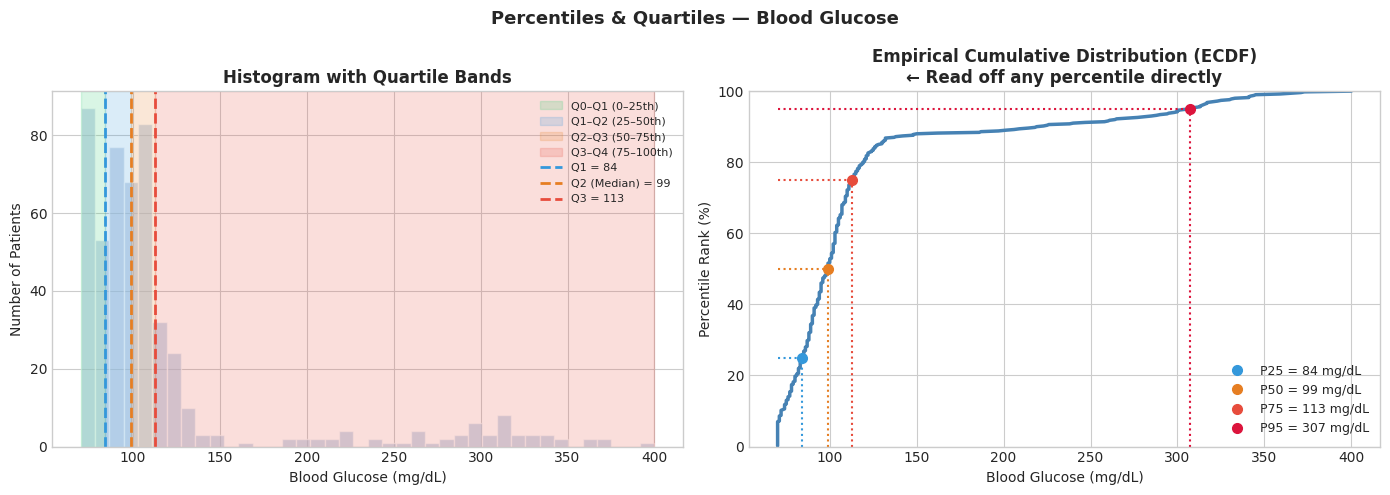

Chart saved as percentiles_quartiles.png


In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Percentiles & Quartiles — Blood Glucose',
             fontsize=13, fontweight='bold')

col = 'Blood_Glucose'
Q1  = df[col].quantile(0.25)
Q2  = df[col].quantile(0.50)
Q3  = df[col].quantile(0.75)
p5  = df[col].quantile(0.05)
p95 = df[col].quantile(0.95)

# ── Left: Histogram with quartile bands shaded ────────────────────
ax1 = axes[0]
ax1.hist(df[col], bins=40, color='lightsteelblue',
         edgecolor='white', alpha=0.6)

# Shade each quartile band a different colour
colours = ['#2ecc71', '#3498db', '#e67e22', '#e74c3c']
labels  = ['Q0–Q1 (0–25th)', 'Q1–Q2 (25–50th)',
           'Q2–Q3 (50–75th)', 'Q3–Q4 (75–100th)']
bounds  = [df[col].min(), Q1, Q2, Q3, df[col].max()]

for i in range(4):
    ax1.axvspan(bounds[i], bounds[i+1],
                alpha=0.18, color=colours[i], label=labels[i])

# Mark Q lines
for val, label, color in [(Q1,'Q1',colours[1]),
                           (Q2,'Q2 (Median)',colours[2]),
                           (Q3,'Q3',colours[3])]:
    ax1.axvline(val, color=color, linewidth=2,
                linestyle='--', label=f'{label} = {val:.0f}')

ax1.set_title('Histogram with Quartile Bands', fontweight='bold')
ax1.set_xlabel('Blood Glucose (mg/dL)')
ax1.set_ylabel('Number of Patients')
ax1.legend(fontsize=8, loc='upper right')

# ── Right: Cumulative Distribution Function (ECDF) ───────────────
ax2 = axes[1]
sorted_glucose = np.sort(df[col].values)
ecdf = np.arange(1, len(sorted_glucose)+1) / len(sorted_glucose)

ax2.plot(sorted_glucose, ecdf * 100,
         color='steelblue', linewidth=2.5)

# Mark key percentiles with dotted crosshairs
for pct, val, col_c in [(25, Q1, colours[1]),
                          (50, Q2, colours[2]),
                          (75, Q3, colours[3]),
                          (95, p95, 'crimson')]:
    ax2.plot([df[col].min(), val], [pct, pct],
             linestyle=':', color=col_c, linewidth=1.5)
    ax2.plot([val, val], [0, pct],
             linestyle=':', color=col_c, linewidth=1.5)
    ax2.plot(val, pct, 'o', color=col_c, markersize=7,
             label=f'P{pct} = {val:.0f} mg/dL')

ax2.set_title('Empirical Cumulative Distribution (ECDF)\n'
              '← Read off any percentile directly',
              fontweight='bold')
ax2.set_xlabel('Blood Glucose (mg/dL)')
ax2.set_ylabel('Percentile Rank (%)')
ax2.legend(fontsize=9)
ax2.set_ylim(0, 100)

plt.tight_layout()
plt.savefig('percentiles_quartiles.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved as percentiles_quartiles.png")

![Pairing](../img/pairing_rule.png)

## Topic 6: Five-Number Summary — Min, Q1, Median, Q3, Max; Boxplots; Outlier Detection

#### 1. Plain-Language Definition
The five-number summary is exactly what it sounds like — five carefully chosen values that together give a complete, outlier-resistant portrait of any distribution. Combined with the IQR from Topic 5, these five numbers are the raw material for the boxplot — the single most information-dense chart in descriptive statistics — and for a principled, mathematical definition of what counts as an outlier.

#### 2. The Medical Analogy — Before Any Math
Think of the five-number summary as a patient triage report written by a ward registrar at handover:

`"The quietest day this month was 1 admission (Min). A typical slow day sits around 3 admissions (Q1). The middle day had 5 (Median). A busy day reaches 8 (Q3). But our worst day ever hit 28 (Max)."`

Five numbers. Any clinician reading that handover instantly understands the full picture — the typical range, the central value, and the extremes — without seeing a single raw data point.
The boxplot is that handover report drawn as a chart. And the outlier detection rule is the registrar's judgement call: "28 admissions is so far beyond our normal busy days that something unusual must have happened — we should investigate." Except instead of clinical intuition, we use a precise mathematical rule based on the IQR.

![Five-Number Summary](../img/boxplot.png)

In [14]:
numeric_cols = ['Age', 'BP_Systolic', 'Cholesterol_LDL',
                'Blood_Glucose', 'Hospital_Stay_Days']

print(f"Five-Number Summary — All Clinical Variables")
print(f"{'─'*75}")
print(f"  {'Variable':<22} {'Min':>6} {'Q1':>7} {'Median':>8} {'Q3':>7} {'Max':>7} {'IQR':>7}")
print(f"  {'─'*70}")

for col in numeric_cols:
    mn  = df[col].min()
    q1  = df[col].quantile(0.25)
    med = df[col].median()
    q3  = df[col].quantile(0.75)
    mx  = df[col].max()
    iqr = q3 - q1
    print(f"  {col:<22} {mn:>6.0f} {q1:>7.1f} {med:>8.1f} {q3:>7.1f} {mx:>7.0f} {iqr:>7.1f}")

print(f"\n  Quick reads:")
print(f"  → Hospital Stay heavily right-skewed: median=3, max=30")
print(f"  → Blood Glucose has widest IQR relative to median — most variable")
print(f"  → Age and LDL look reasonably symmetric (Q2 sits centrally in Q1–Q3)")

Five-Number Summary — All Clinical Variables
───────────────────────────────────────────────────────────────────────────
  Variable                  Min      Q1   Median      Q3     Max     IQR
  ──────────────────────────────────────────────────────────────────────
  Age                        39    66.0     77.0    85.0      85    19.0
  BP_Systolic                90   120.0    133.0   146.0     200    26.0
  Cholesterol_LDL            60   108.0    129.5   152.0     239    44.0
  Blood_Glucose              70    84.0     99.0   113.0     400    29.0
  Hospital_Stay_Days          1     1.0      2.0     4.0      24     3.0

  Quick reads:
  → Hospital Stay heavily right-skewed: median=3, max=30
  → Blood Glucose has widest IQR relative to median — most variable
  → Age and LDL look reasonably symmetric (Q2 sits centrally in Q1–Q3)


In [15]:
def tukey_outliers(series, k=1.5):
    """
    Apply Tukey's fence rule to detect outliers.
    k=1.5 → mild outliers (standard)
    k=3.0 → extreme outliers (likely errors)
    Returns: lower fence, upper fence, outlier values
    """
    Q1  = series.quantile(0.25)
    Q3  = series.quantile(0.75)
    IQR = Q3 - Q1

    lower_fence = Q1 - k * IQR
    upper_fence = Q3 + k * IQR

    outliers = series[(series < lower_fence) | (series > upper_fence)]
    return lower_fence, upper_fence, outliers

print(f"Tukey Outlier Detection — All Clinical Variables")
print(f"{'─'*70}")

for col in numeric_cols:
    lf, uf, outliers = tukey_outliers(df[col], k=1.5)
    pct = len(outliers) / len(df) * 100
    print(f"\n  {col}")
    print(f"    Fences     : [{lf:.1f}, {uf:.1f}]")
    print(f"    Outliers   : {len(outliers)} patients ({pct:.1f}% of panel)")
    if len(outliers) > 0:
        print(f"    Range      : {outliers.min():.0f} – {outliers.max():.0f}")
        print(f"    Direction  : {'upper tail ↑' if outliers.mean() > df[col].median() else 'lower tail ↓'}")

Tukey Outlier Detection — All Clinical Variables
──────────────────────────────────────────────────────────────────────

  Age
    Fences     : [37.5, 113.5]
    Outliers   : 0 patients (0.0% of panel)

  BP_Systolic
    Fences     : [81.0, 185.0]
    Outliers   : 14 patients (2.8% of panel)
    Range      : 186 – 200
    Direction  : upper tail ↑

  Cholesterol_LDL
    Fences     : [42.0, 218.0]
    Outliers   : 3 patients (0.6% of panel)
    Range      : 222 – 239
    Direction  : upper tail ↑

  Blood_Glucose
    Fences     : [40.5, 156.5]
    Outliers   : 60 patients (12.0% of panel)
    Range      : 162 – 400
    Direction  : upper tail ↑

  Hospital_Stay_Days
    Fences     : [-3.5, 8.5]
    Outliers   : 46 patients (9.2% of panel)
    Range      : 9 – 24
    Direction  : upper tail ↑
